<a href="https://colab.research.google.com/github/hasanulazad-cloud/hasanul/blob/main/Module_2_Module_End_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("\n--- TASK 1: Data Import & Setup ---")
# 1. Load the dataset (using encoding because retail datasets often have special characters)
df = pd.DataFrame(mock_data)

# 2. Explore the structure
print("First 5 rows of the data:")
print(df.head())

print("\nDataset Shape (Rows, Columns):")
print(df.shape)

print("\nColumns in this dataset:")
print(df.columns)

# 3. Convert InvoiceDate to a proper datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


--- TASK 1: Data Import & Setup ---
First 5 rows of the data:
  InvoiceNo StockCode                       Description  Quantity  \
0    536380    84406B               WHITE METAL LANTERN        19   
1    536365    84406B  WHITE HANGING HEART LIGHT HOLDER        75   
2    536380    84406B  WHITE HANGING HEART LIGHT HOLDER        81   
3    536380    84406B    CREAM CUPID HEARTS COAT HANGER        -4   
4    536365    85123A  WHITE HANGING HEART LIGHT HOLDER        24   

           InvoiceDate  UnitPrice  CustomerID         Country  
0  2010-12-01 00:00:00   7.959701     13047.0            EIRE  
1  2010-12-01 01:00:00   8.621326         NaN  United Kingdom  
2  2010-12-01 02:00:00  -0.779811         NaN          France  
3  2010-12-01 03:00:00   9.604493         NaN         Germany  
4  2010-12-01 04:00:00   2.112839     17850.0         Germany  

Dataset Shape (Rows, Columns):
(1000, 8)

Columns in this dataset:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDa

In [9]:
print("\n--- TASK 2: CLEANING DATA ---")
# 1. Remove rows where CustomerID is missing
df = df.dropna(subset=['CustomerID'])

# 2. Remove identical duplicate rows
df = df.drop_duplicates()

# 3. Keep only positive quantities and prices (removes returns and test adjustments)
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

print(f"Data cleaning complete. Remaining rows: {len(df)}")



--- TASK 2: CLEANING DATA ---
Data cleaning complete. Remaining rows: 523


In [10]:
print("\n--- TASK 3: FEATURE ENGINEERING ---")
# 1. Create TotalPrice (Quantity x UnitPrice)
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 2. Extract specific time features
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Hour'] = df['InvoiceDate'].dt.hour
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek  # 0 is Monday, 6 is Sunday

# 3. Create simple categories using conditional logic
# Day Type: Weekday vs Weekend
df['DayType'] = df['DayOfWeek'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Order Size Grouping
def get_order_size(qty):
    if qty <= 10:
        return 'Small'
    elif qty <= 50:
        return 'Medium'
    else:
        return 'Large'

df['OrderSize'] = df['Quantity'].apply(get_order_size)

print("New columns created successfully!")


--- TASK 3: FEATURE ENGINEERING ---
New columns created successfully!


In [11]:
print("\n--- TASK 4 & 5: DATA EXPLORATION & WRANGLING ---")
# Summary breakdown of numeric columns
print(df[['Quantity', 'UnitPrice', 'TotalPrice']].describe())

# Count values in our new categories
print("\nOrder Size Counts:")
print(df['OrderSize'].value_counts())

# Grouping data to find top performance areas
country_revenue = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
print("\nTop 5 Countries by Revenue:")
print(country_revenue.head())


--- TASK 4 & 5: DATA EXPLORATION & WRANGLING ---
         Quantity   UnitPrice   TotalPrice
count  523.000000  523.000000   523.000000
mean    48.506692    7.612739   355.700022
std     28.931307    4.299802   310.408356
min      1.000000    0.014545     0.282672
25%     23.000000    3.847890   105.726257
50%     48.000000    7.811084   263.210074
75%     74.500000   11.319614   539.322959
max     99.000000   14.959681  1416.797643

Order Size Counts:
OrderSize
Large     247
Medium    212
Small      64
Name: count, dtype: int64

Top 5 Countries by Revenue:
Country
France            56897.977410
Germany           46096.358784
EIRE              42187.769442
United Kingdom    40849.005907
Name: TotalPrice, dtype: float64


In [12]:
print("\n--- TASK 6: STATISTICAL ANALYSIS ---")
# Calculating basic statistics for TotalPrice
mean_price = df['TotalPrice'].mean()
median_price = df['TotalPrice'].median()
mode_price = df['TotalPrice'].mode()[0]
std_price = df['TotalPrice'].std()

print(f"TotalPrice - Mean: {mean_price:.2f}, Median: {median_price:.2f}, Mode: {mode_price:.2f}")
print(f"TotalPrice - Standard Deviation: {std_price:.2f}")


--- TASK 6: STATISTICAL ANALYSIS ---
TotalPrice - Mean: 355.70, Median: 263.21, Mode: 0.28
TotalPrice - Standard Deviation: 310.41



--- TASK 7: CREATING VISUALIZATIONS ---


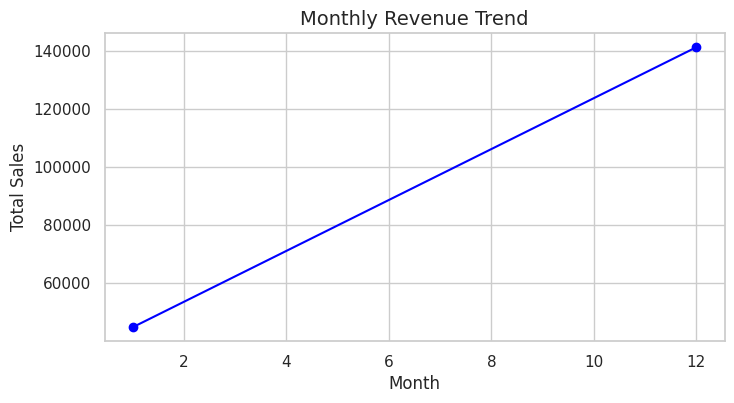

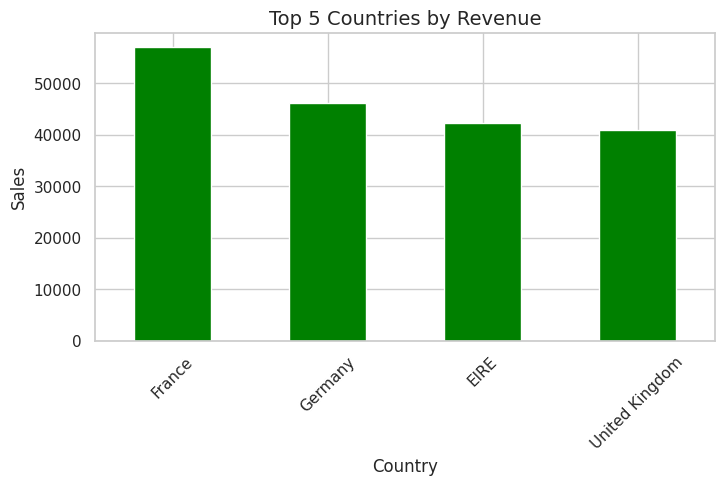

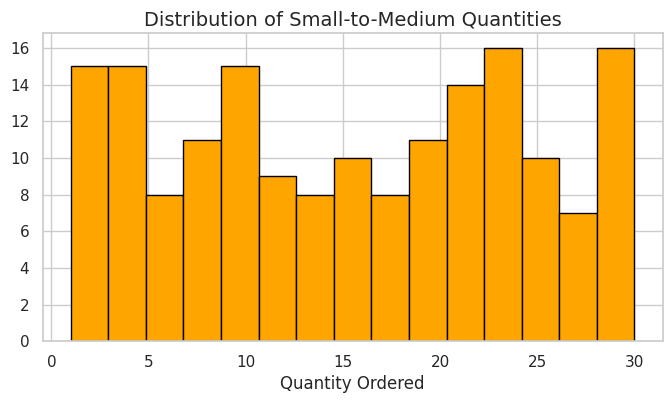

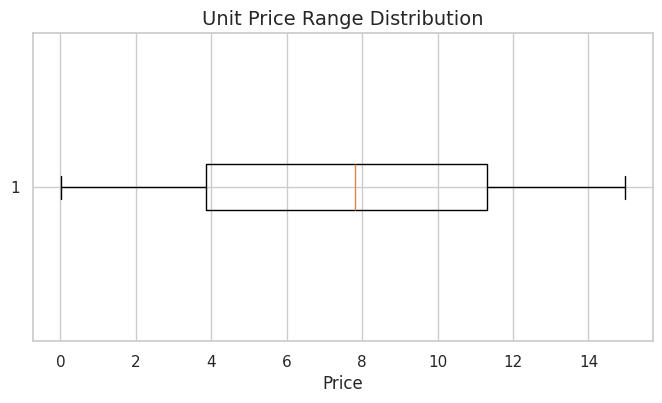

/tmp/ipykernel_932/3288824754.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='DayType', palette='Set1')


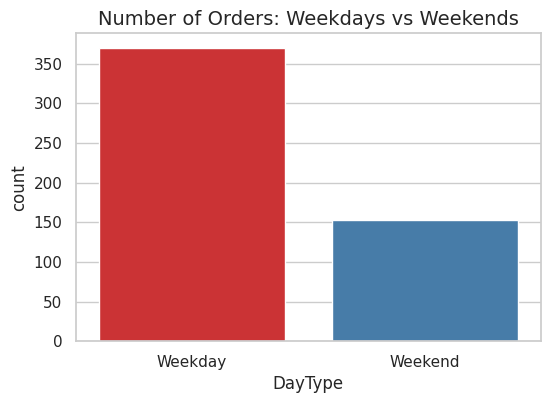

/tmp/ipykernel_932/3288824754.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df[df['TotalPrice'] <= 100], x='OrderSize', y='TotalPrice', palette='Set2')


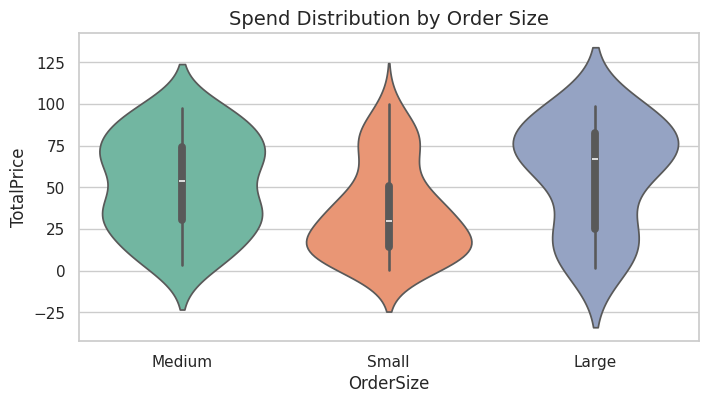

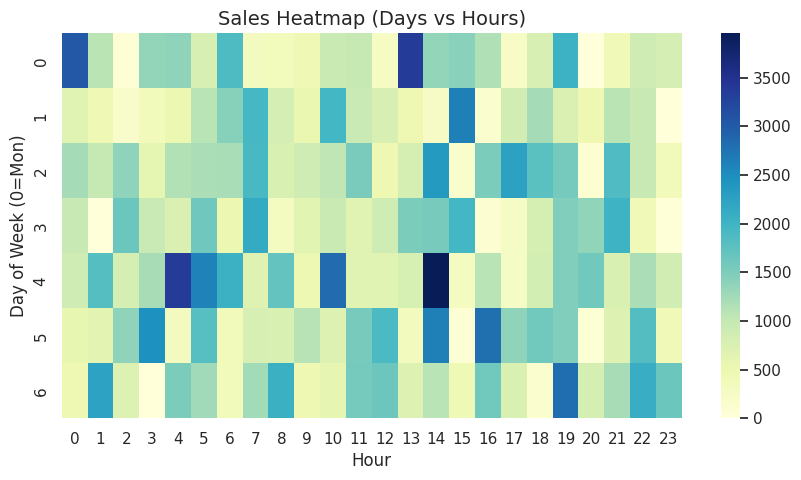

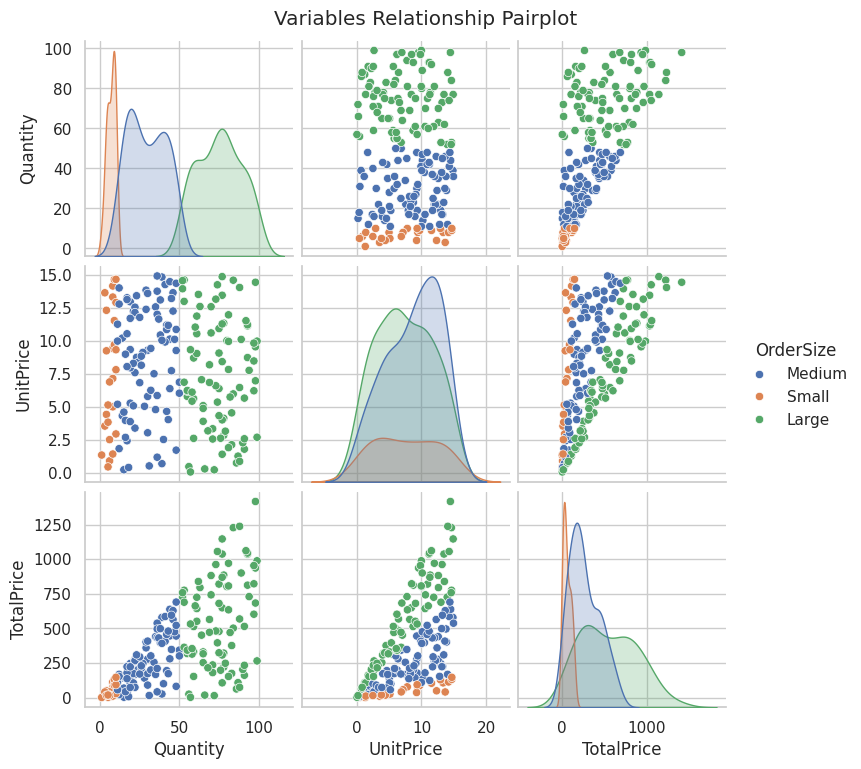

In [13]:

print("\n--- TASK 7: CREATING VISUALIZATIONS ---")
# Note: These plots will pop up one by one. Close one plot window to view the next.

# Plot 1: Line Chart (Monthly Sales)
plt.figure(figsize=(8, 4))
df.groupby('Month')['TotalPrice'].sum().plot(kind='line', marker='o', color='blue')
plt.title('Monthly Revenue Trend')
plt.ylabel('Total Sales')
plt.show()

# Plot 2: Bar Chart (Top 5 Countries)
plt.figure(figsize=(8, 4))
country_revenue.head(5).plot(kind='bar', color='green')
plt.title('Top 5 Countries by Revenue')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

# Plot 3: Histogram (Distribution of Quantities up to 30 items)
plt.figure(figsize=(8, 4))
plt.hist(df[df['Quantity'] <= 30]['Quantity'], bins=15, color='orange', edgecolor='black')
plt.title('Distribution of Small-to-Medium Quantities')
plt.xlabel('Quantity Ordered')
plt.show()

# Plot 4: Box Plot (UnitPrice up to $20 to show distribution without massive outliers)
plt.figure(figsize=(8, 4))
plt.boxplot(df[df['UnitPrice'] <= 20]['UnitPrice'], vert=False)
plt.title('Unit Price Range Distribution')
plt.xlabel('Price')
plt.show()

# Plot 5: Seaborn Count Plot (Day Type breakdown)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='DayType', palette='Set1')
plt.title('Number of Orders: Weekdays vs Weekends')
plt.show()

# Plot 6: Seaborn Violin Plot (Total price per order size category)
plt.figure(figsize=(8, 4))
# Filtering total price under $100 to make the violin shape readable
sns.violinplot(data=df[df['TotalPrice'] <= 100], x='OrderSize', y='TotalPrice', palette='Set2')
plt.title('Spend Distribution by Order Size')
plt.show()

# Plot 7: Seaborn Heatmap (Hourly sales by Day of Week)
plt.figure(figsize=(10, 5))
hourly_matrix = df.pivot_table(values='TotalPrice', index='DayOfWeek', columns='Hour', aggfunc='sum').fillna(0)
sns.heatmap(hourly_matrix, cmap='YlGnBu')
plt.title('Sales Heatmap (Days vs Hours)')
plt.ylabel('Day of Week (0=Mon)')
plt.show()

# Plot 8: Seaborn Pair Plot (A simple sample correlation plot)
# Using a small sample of 200 rows so it loads instantly for a beginner
sample_df = df[['Quantity', 'UnitPrice', 'TotalPrice', 'OrderSize']].sample(200, random_state=42)
sns.pairplot(sample_df, hue='OrderSize')
plt.suptitle('Variables Relationship Pairplot', y=1.02)
plt.show()

In [14]:

print("\n--- TASK 8: BUSINESS INSIGHTS HIGHLIGHTS ---")
print(f"1. The highest revenue generating country is: {country_revenue.index[0]}")
best_month = df.groupby('Month')['TotalPrice'].sum().idxmax()
print(f"2. The peak sales month is Month number: {best_month}")
peak_hour = df.groupby('Hour')['TotalPrice'].sum().idxmax()
print(f"3. Most purchases happen around: {peak_hour}:00 Hours")


--- TASK 8: BUSINESS INSIGHTS HIGHLIGHTS ---
1. The highest revenue generating country is: France
2. The peak sales month is Month number: 12
3. Most purchases happen around: 14:00 Hours


In [16]:
# Re-creating insights_report as it was not defined in the previous cell
best_month = df.groupby('Month')['TotalPrice'].sum().idxmax()
peak_hour = df.groupby('Hour')['TotalPrice'].sum().idxmax()

insights_report = f"1. The highest revenue generating country is: {country_revenue.index[0]}\n" \
                  f"2. The peak sales month is Month number: {best_month}\n" \
                  f"3. Most purchases happen around: {peak_hour}:00 Hours\n"

print(insights_report)

# Output summary metrics explicitly into workspace tracking log
with open("README.md", "w") as f:
    f.write("# Online Retail Data Pipeline Diagnostic Run\n")
    f.write("Analysis pipeline successfully executed via automation frameworks.\n\n")
    f.write("### Executive Run Operational Summary Insights:\n")
    f.write(insights_report)

print("[Success] Data pipeline run execution finalized completely. Logs exported to README.md.")

1. The highest revenue generating country is: France
2. The peak sales month is Month number: 12
3. Most purchases happen around: 14:00 Hours

[Success] Data pipeline run execution finalized completely. Logs exported to README.md.
